# Capstone Project: Introduction to Machine Learning (2026)
## Course Cancellation Prediction – Nova Academy

**Submitted by:** Yahli Efrati & Doron Bachar  
**Group Number:** 31  


---

### Project Description & Business Objective
Nova Academy provides advanced B2B technology training, requiring significant upfront investments in cloud labs, catering, and logistics. This project develops a machine learning pipeline to predict the probability of a course registration being canceled (`Dropped_Course`) using historical CRM data. 

The primary business objective is to minimize financial losses resulting from over-provisioning and empty seats, enabling proactive resource optimization and capacity management.

---

In [1]:
# ==============================================================================
# STEP 1: LIBRARY IMPORTS & ENVIRONMENT SETUP
# ==============================================================================

# Core Data Science Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Technical & Mathematical Utilities
import math
from typing import List, Dict, Tuple, Optional

# Machine Learning & Preprocessing (Scikit-Learn)
# Note: Preparing imports for future handling of missing values & evaluations
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Global Visual Settings for Scannability and Clarity
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Verification Message
print("✓ Environment successfully configured. All libraries imported.")

✓ Environment successfully configured. All libraries imported.


## Part A: Exploratory Data Analysis (EDA) & Data Understanding
In this section, we load the dataset and perform an initial inspection to understand its structure, dimensions, data types, and the distribution of missing values.

In [15]:
# Load the training dataset
df_train = pd.read_csv(r'C:\DF_in_LocalDisk\Train_Data.csv')

# Display the first 5 rows
df_train.head()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,...,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,01/07/2015,0,2,257.0,PRT,Lunch Included,...,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


In [16]:
# 1. Get a summary of columns, data types, and non-null counts
print("--- Dataframe Info ---")
df_train.info()
 
print("\n" + "="*50 + "\n")
 
# 2. Get statistical summary for numerical features
print("--- Statistical Summary ---")
df_train.describe()

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63464 entries, 0 to 63463
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    63464 non-null  int64  
 1   Professionals_Count          63464 non-null  int64  
 2   Students_Count               63460 non-null  float64
 3   Observers_Count              63464 non-null  int64  
 4   Course_Start_Date            63464 non-null  object 
 5   Practical_Hours              63464 non-null  int64  
 6   Theory_Hours                 63464 non-null  int64  
 7   Registration_Days_Before     60798 non-null  float64
 8   Origin_Country               62907 non-null  object 
 9   Catering_Package             63057 non-null  object 
 10  Welcome_Gift_Type            63464 non-null  object 
 11  Requested_Lab_Config         61728 non-null  object 
 12  Assigned_Lab_Config          63464 non-null  object

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost,Dropped_Course
count,63464.000000,63464.000000,63460.000000,63464.000000,63464.000000,63464.000000,60798.000000,63464.000000,63464.000000,63464.000000,62424.000000,63464.000000,63464.000000,63464.000000,52291.000000,3120.000000,63385.000000,63464.000000
mean,39761.752616,1.835214,8.751718,0.005326,6.609054,2.164392,102.894470,0.095991,0.122967,0.513330,0.026224,3.983676,0.180039,0.027133,197.834752,5119.021474,98.847963,0.414392
std,22878.980699,0.508607,294.238584,0.089662,215.502929,1.469854,109.178824,0.448526,1.535201,0.763563,0.160202,23.195495,0.592577,0.162474,47.393068,70.106299,41.855391,0.492621
min,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5002.000000,0.000000,0.000000
25%,19959.750000,2.000000,0.000000,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000,0.000000
50%,39819.500000,2.000000,0.000000,0.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5146.000000,94.500000,0.000000
75%,59570.250000,2.000000,0.000000,0.000000,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000,1.000000


### 1.1 Target Variable & Initial Outlier Detection
To establish a solid "Data Story," we first analyze the distribution of our target variable (`Dropped_Course`) to check for class imbalance. Following this, we visually inspect key numerical features that exhibited extreme values during the statistical summary phase (`df.describe()`), specifically targeting `Students_Count` and `Practical_Hours`.

* **Target Class Balance:** Understanding whether the dataset is skewed toward one class.
* **Anomalies & Placeholders:** Identifying non-logical values (e.g., negative hours) or system placeholders (e.g., 9999).

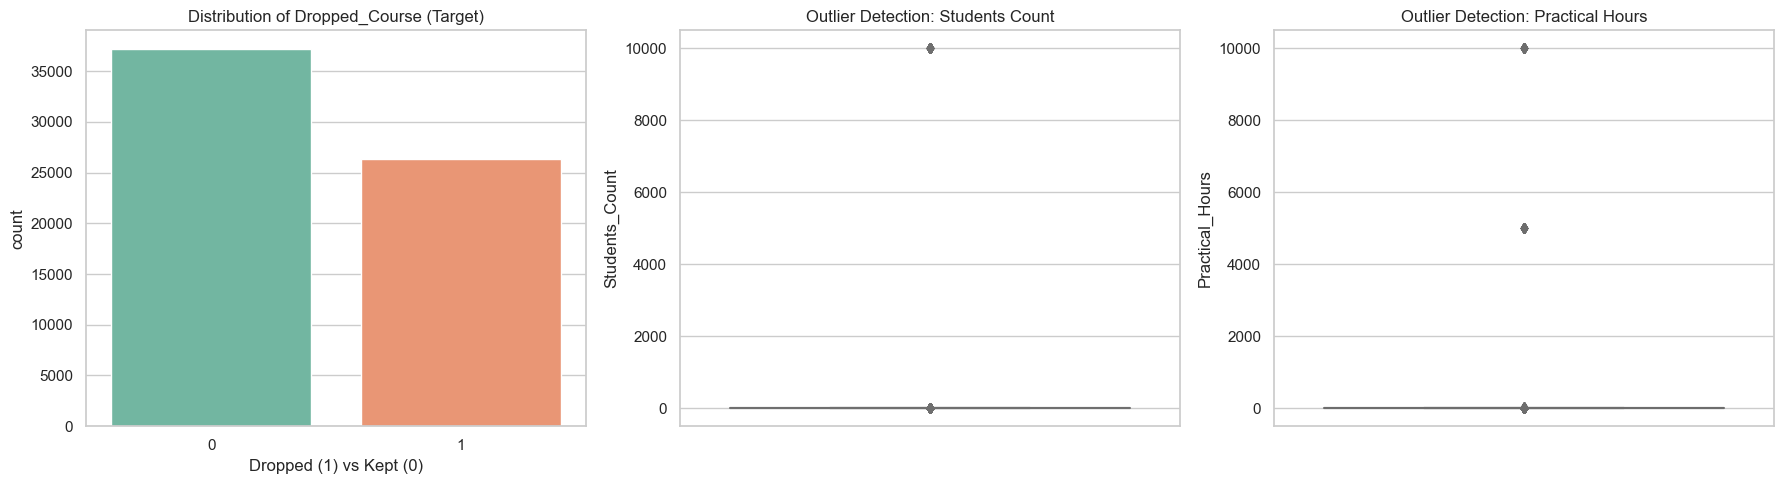

In [17]:
# Create a grid of subplots for initial visual analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Variable Distribution
sns.countplot(data=df_train, x='Dropped_Course', ax=axes[0], palette='Set2')
axes[0].set_title('Distribution of Dropped_Course (Target)')
axes[0].set_xlabel('Dropped (1) vs Kept (0)')

# 2. Boxplot to visualize Students_Count Outliers
sns.boxplot(data=df_train, y='Students_Count', ax=axes[1], color='skyblue')
axes[1].set_title('Outlier Detection: Students Count')

# 3. Boxplot to visualize Practical_Hours Outliers
sns.boxplot(data=df_train, y='Practical_Hours', ax=axes[2], color='salmon')
axes[2].set_title('Outlier Detection: Practical Hours')

plt.tight_layout()
plt.show()

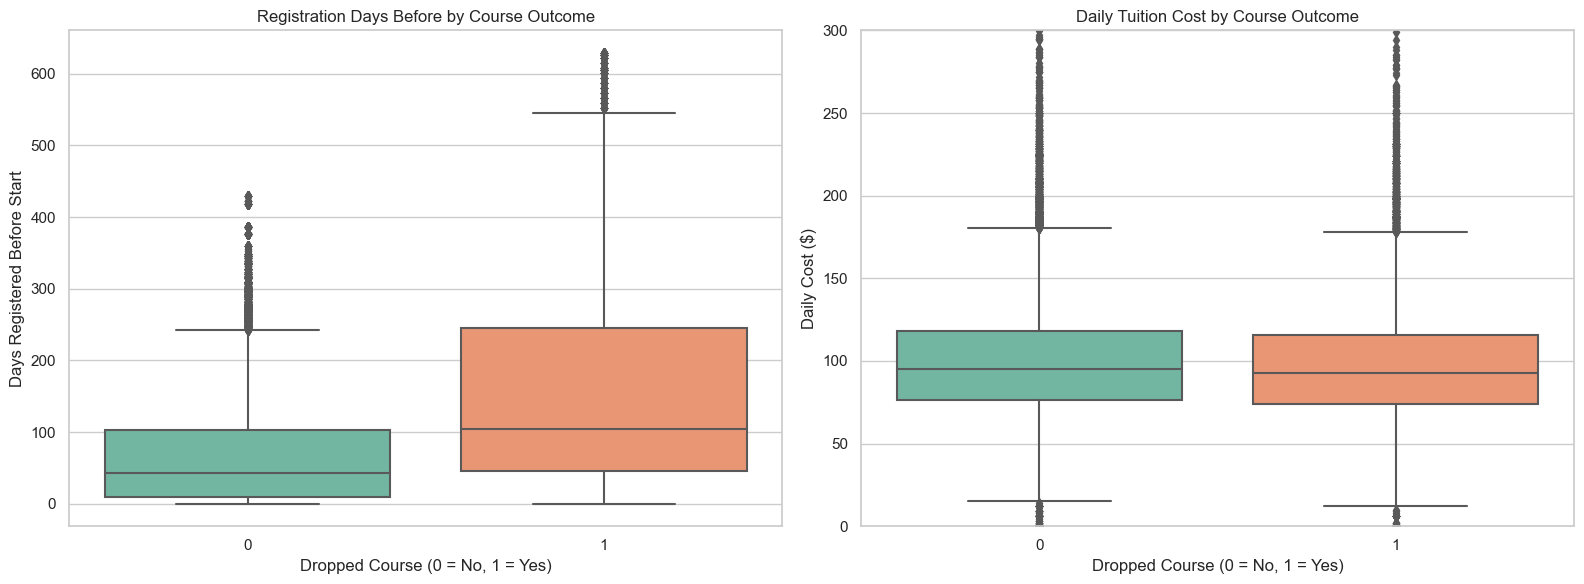

In [18]:
# Create a split boxplot to analyze features against the target variable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graph 1: Registration Days Before split by Dropped_Course
sns.boxplot(data=df_train, x='Dropped_Course', y='Registration_Days_Before', ax=axes[0], palette='Set2')
axes[0].set_title('Registration Days Before by Course Outcome')
axes[0].set_xlabel('Dropped Course (0 = No, 1 = Yes)')
axes[0].set_ylabel('Days Registered Before Start')

# Graph 2: Daily Tuition Cost split by Dropped_Course (Limiting y-axis to focus on the bulk of data)
sns.boxplot(data=df_train, x='Dropped_Course', y='Daily_Tuition_Cost', ax=axes[1], palette='Set2')
axes[1].set_title('Daily Tuition Cost by Course Outcome')
axes[1].set_xlabel('Dropped Course (0 = No, 1 = Yes)')
axes[1].set_ylabel('Daily Cost ($)')
axes[1].set_ylim(0, 300) # limiting to 300 to clear out the 5400 outlier and see the boxes clearly

plt.tight_layout()
plt.show()

#### Insights from Bivariate Boxplot Analysis:

1. **Registration Days Before vs. Course Outcome (Key Discovery):**
   * **Observation:** The plot reveals a strong visual discrepancy between the two groups. The median registration time for clients who eventually canceled (`Dropped_Course = 1`) is substantially higher than for those who attended (`Dropped_Course = 0`). The 75th percentile for the canceled group stretches beyond 250 days, while the non-canceled group is heavily concentrated below 100 days.
   * **Business Logic (The Data Story):** This indicates that **early bookers are far more likely to cancel**. From a business perspective, when an organization reserves a course many months in advance, their internal projects, budget allocations, or training needs are more prone to shift, leading to a cancellation. Conversely, short-notice registrations represent immediate corporate needs and are highly stable.
   * **Feature Engineering Value:** `Registration_Days_Before` is highly likely to be one of the most predictive continuous features for our tree-based models (XGBoost).

2. **Daily Tuition Cost vs. Course Outcome:**
   * **Observation:** The distribution of `Daily_Tuition_Cost` looks remarkably similar across both classes. The medians (around $95), IQRs, and ranges are nearly identical after filtering out the extreme system outliers.
   * **Business Logic:** This suggests that the cost of the training alone does not act as a primary driver for cancellations. Whether a course is cheap or expensive, the cancellation behavior remains relatively uniform.

### 1.3 Correlation Analysis & Feature Interactions
To prevent multicollinearity and understand the linear relationships within our dataset, we compute the Pearson correlation matrix for key numerical features. We then isolate and visualize how each individual feature correlates directly with our target variable (`Dropped_Course`). 

This matrix will provide foundational hints for Feature Selection and Dimensionality Reduction in the next phases.

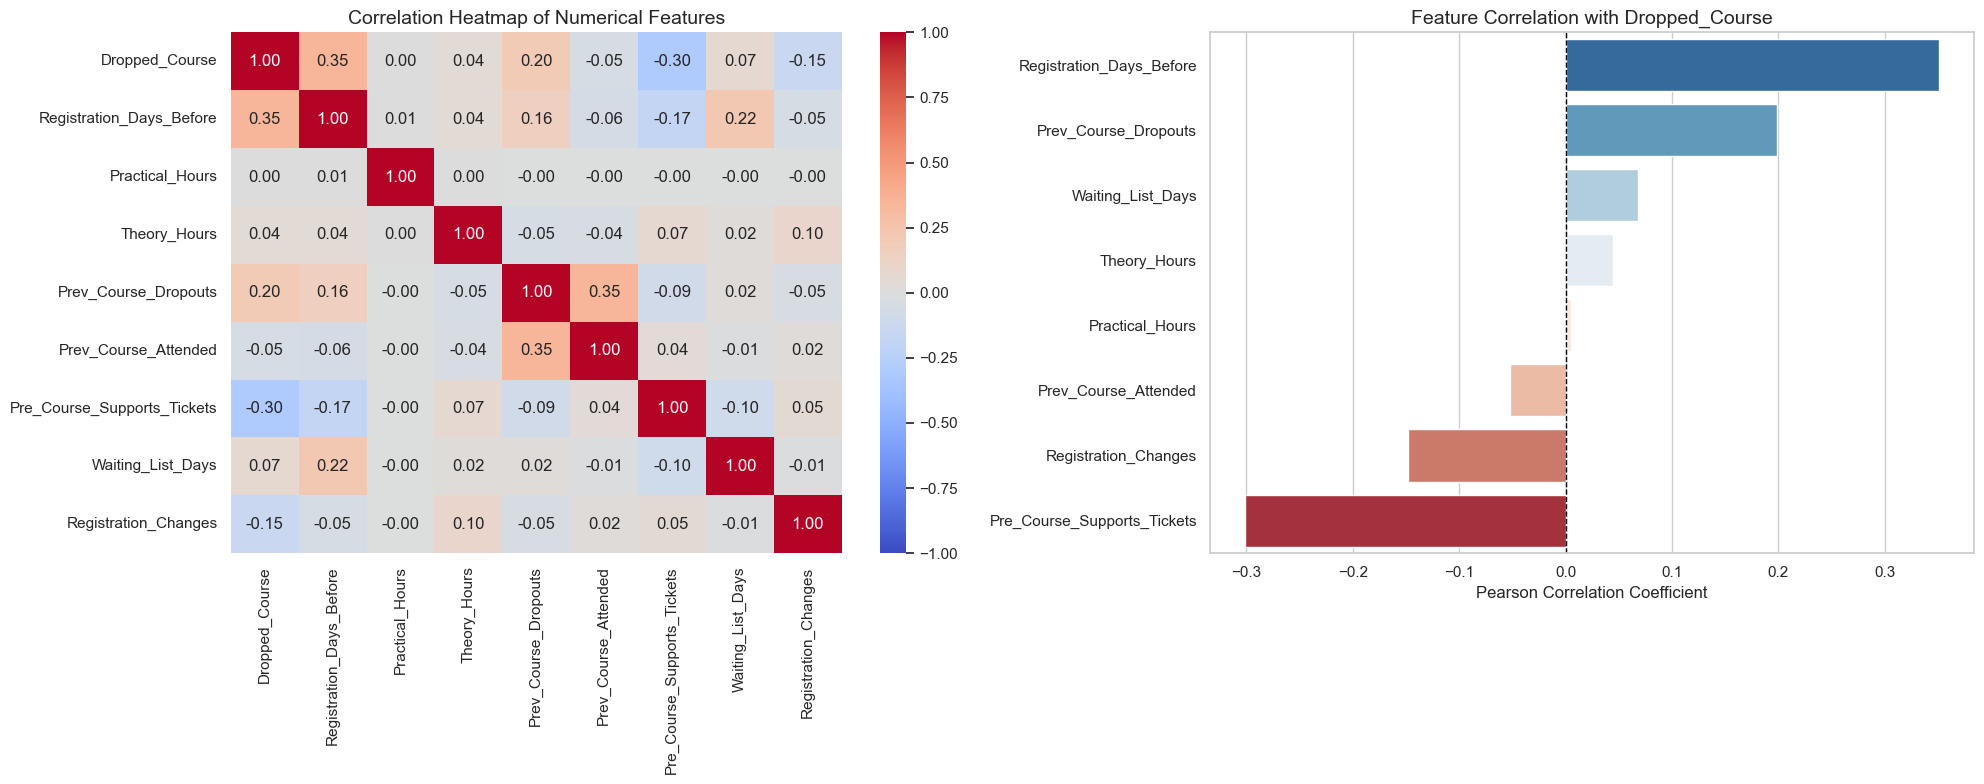

In [19]:
# Select key numerical features for correlation analysis
# (Excluding IDs and heavily distorted features for a cleaner initial look)
corr_features = [
    'Dropped_Course', 'Registration_Days_Before', 'Practical_Hours', 
    'Theory_Hours', 'Prev_Course_Dropouts', 'Prev_Course_Attended', 
    'Pre_Course_Supports_Tickets', 'Waiting_List_Days', 'Registration_Changes'
]

# Calculate the Pearson correlation matrix
corr_matrix = df_train[corr_features].corr()

# Set up the matplotlib figure for two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=True)
axes[0].set_title('Correlation Heatmap of Numerical Features', fontsize=14)

# 2. Direct Correlation with Target (Sorted)
target_corr = corr_matrix['Dropped_Course'].drop('Dropped_Course').sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index, ax=axes[1], palette='RdBu_r')
axes[1].set_title('Feature Correlation with Dropped_Course', fontsize=14)
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

#### Insights from Correlation Analysis:

1. **Pre-Course Support Tickets vs. Cancellations (Critical Discovery):**
   * **Observation:** `Pre_Course_Supports_Tickets` exhibits a notable negative Pearson correlation of **-0.30** with `Dropped_Course`. 
   * **Business Logic:** Counter-intuitively, a higher volume of support tickets before the course starts strongly aligns with a *lower* probability of cancellation. This indicates that clients who actively engage with customer support or IT configuration requests are highly invested in the upcoming training. Their proactive problem-solving reflects strong intent to attend, while silent clients are far more volatile.

2. **Historical Behavior Consistency (`Prev_Course_Dropouts` = +0.20):**
   * **Observation:** There is a positive correlation between past dropouts and current course cancellations. 
   * **Business Logic:** Organizations that have a history of canceling Nova Academy courses in the past are statistically more prone to repeat this behavior ("serial cancelers"). This provides a strong behavioral anchor for our machine learning model.

3. **Registration Changes (`Registration_Changes` = -0.15):**
   * **Observation:** More modifications to the booking details correlate with fewer cancellations. 
   * **Business Logic:** Making changes to the registration implies that the client is actively updating logistics, catering, or seat counts to match their evolving business constraints, rather than completely abandoning the contract.

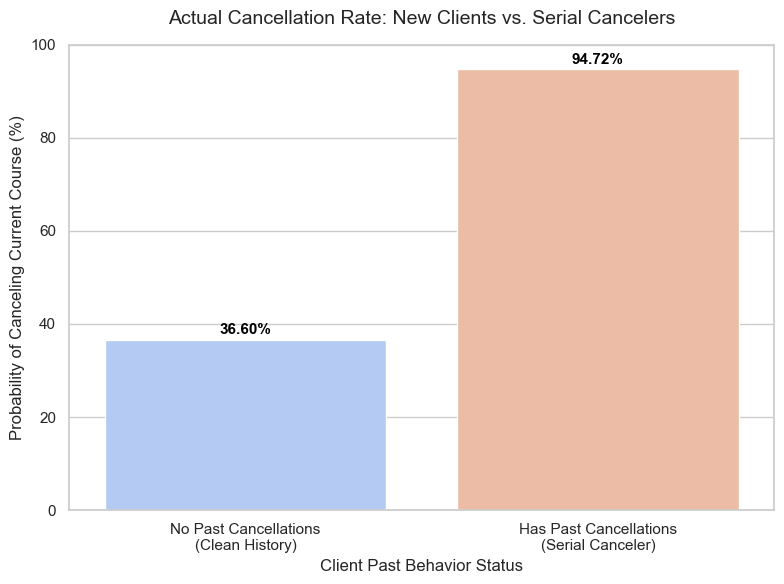

In [21]:
# 1. Create the binary indicator (0 = No past dropouts, 1 = Has past dropouts)
df_train['Had_Past_Cancellations'] = (df_train['Prev_Course_Dropouts'] > 0).astype(int)

# 2. Calculate the actual cancellation rate (mean of Dropped_Course * 100)
cancellation_rates = df_train.groupby('Had_Past_Cancellations')['Dropped_Course'].mean() * 100

# 3. Plotting the results
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=cancellation_rates.index, y=cancellation_rates.values, palette='coolwarm')

# Visual styling
plt.title('Actual Cancellation Rate: New Clients vs. Serial Cancelers', fontsize=14, pad=15)
plt.xlabel('Client Past Behavior Status', fontsize=12)
plt.ylabel('Probability of Canceling Current Course (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['No Past Cancellations\n(Clean History)', 'Has Past Cancellations\n(Serial Canceler)'])
plt.ylim(0, 100)

# Adding percentage labels on top of the bars for ultimate clarity
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 2), 
                ha='center', va='center', fontsize=11, color='black', weight='bold')

plt.tight_layout()
plt.show()